In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('ToyotaCorolla - MLR.csv')

In [3]:
data_raw = data.copy()
data_outlier = data.copy()

In [4]:
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [7]:
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [8]:
data.rename(columns={'Age_08_04': 'Age'}, inplace=True)

In [9]:
data.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


### Visualization

#### 1. Histogram

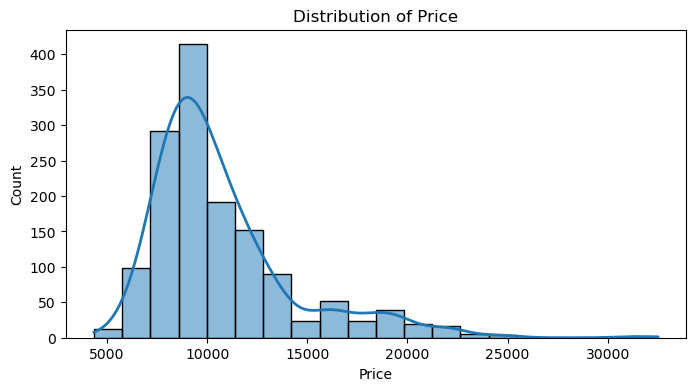

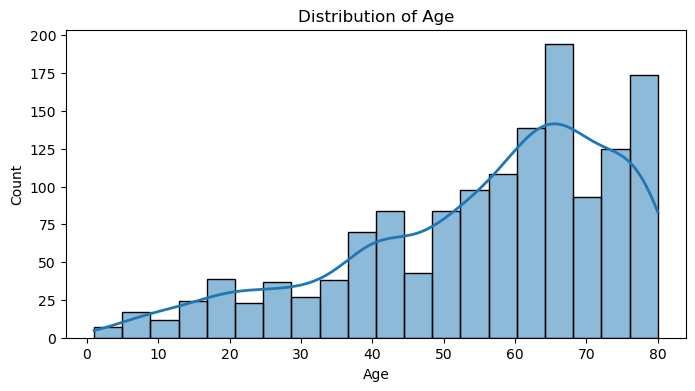

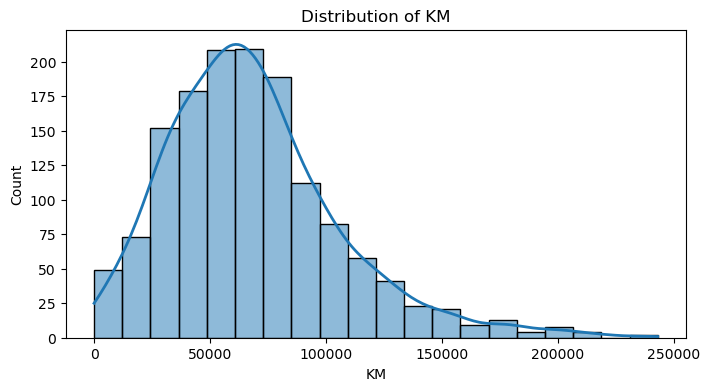

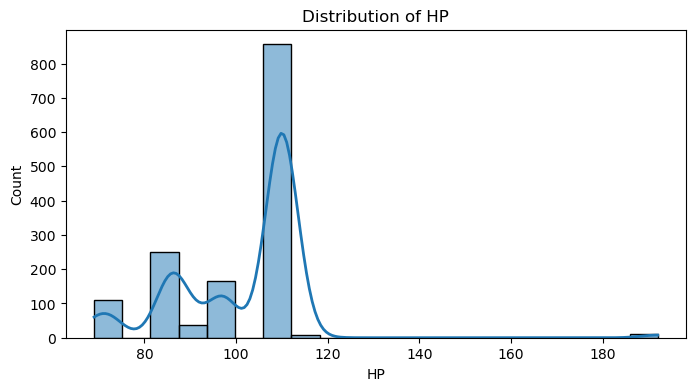

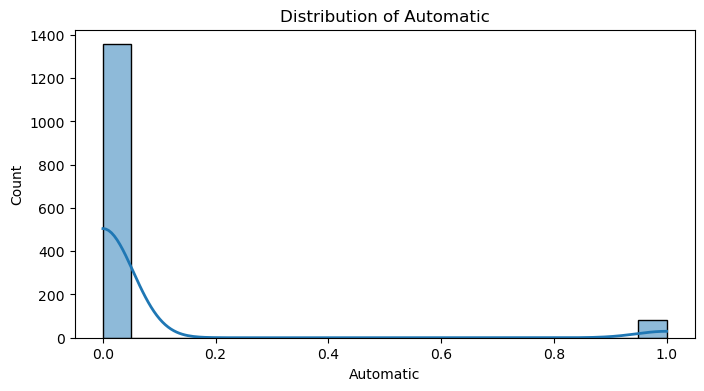

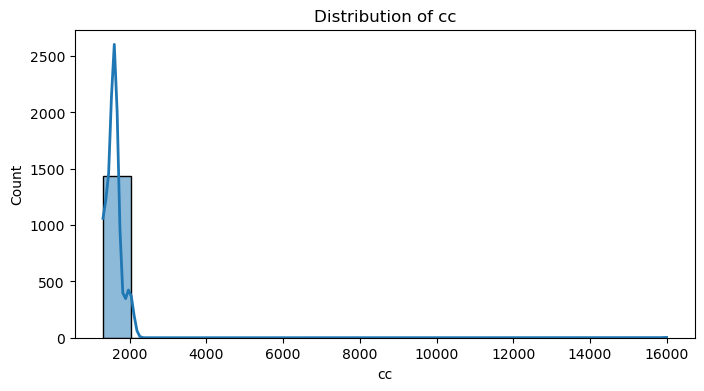

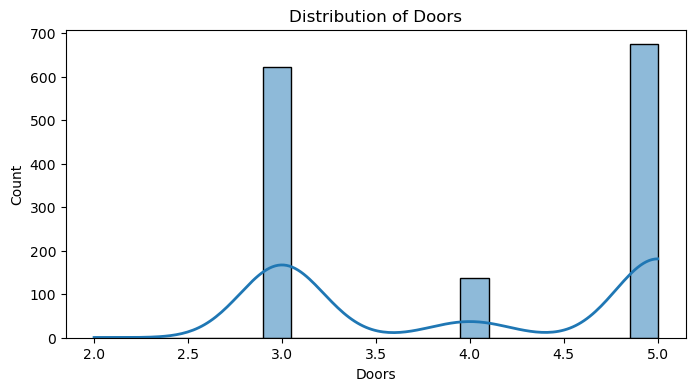

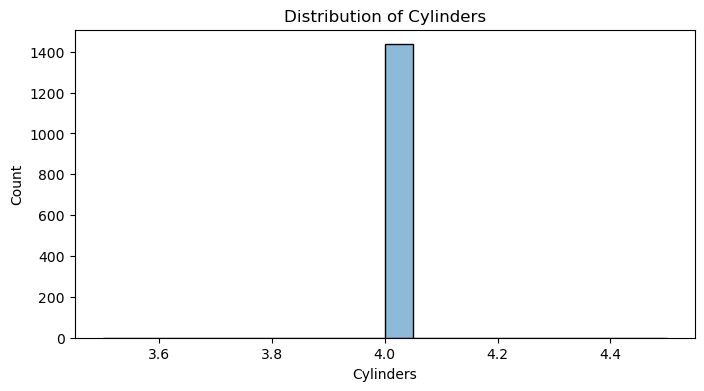

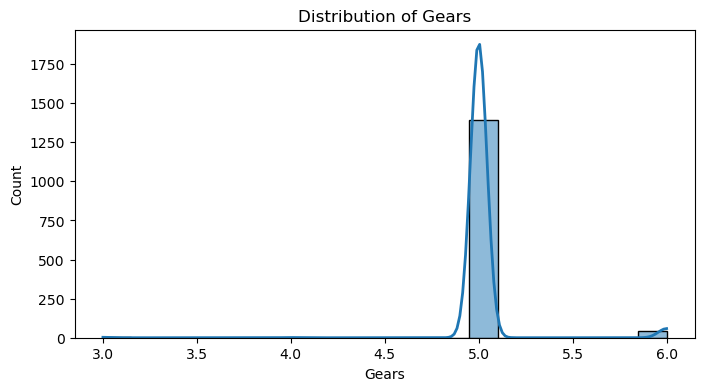

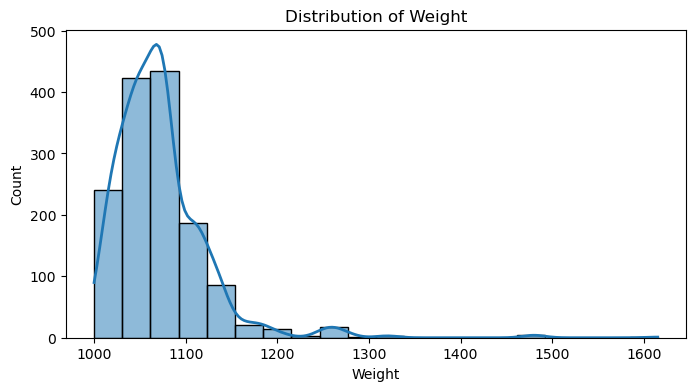

In [10]:
num_col = data.select_dtypes(include=['int64','float64'])
for col in num_col:
    plt.figure(figsize = (8,4)) 
    plt.title(f'Distribution of {col}')
    sns.histplot(data[col],edgecolor='k',bins = 20,kde=True,line_kws= {'linewidth':2})
    #plt.tight_layout()
    plt.show()

#### 2. HeatMap for Correlation

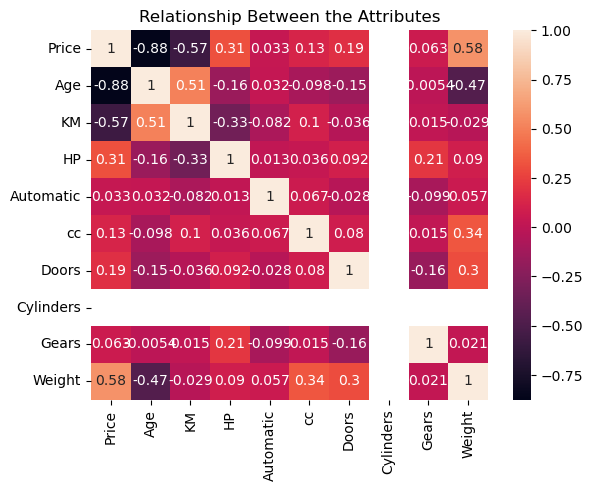

In [11]:
corre_data = num_col.corr()
plt.title("Relationship Between the Attributes")
sns.heatmap(corre_data,annot=True)
plt.show()

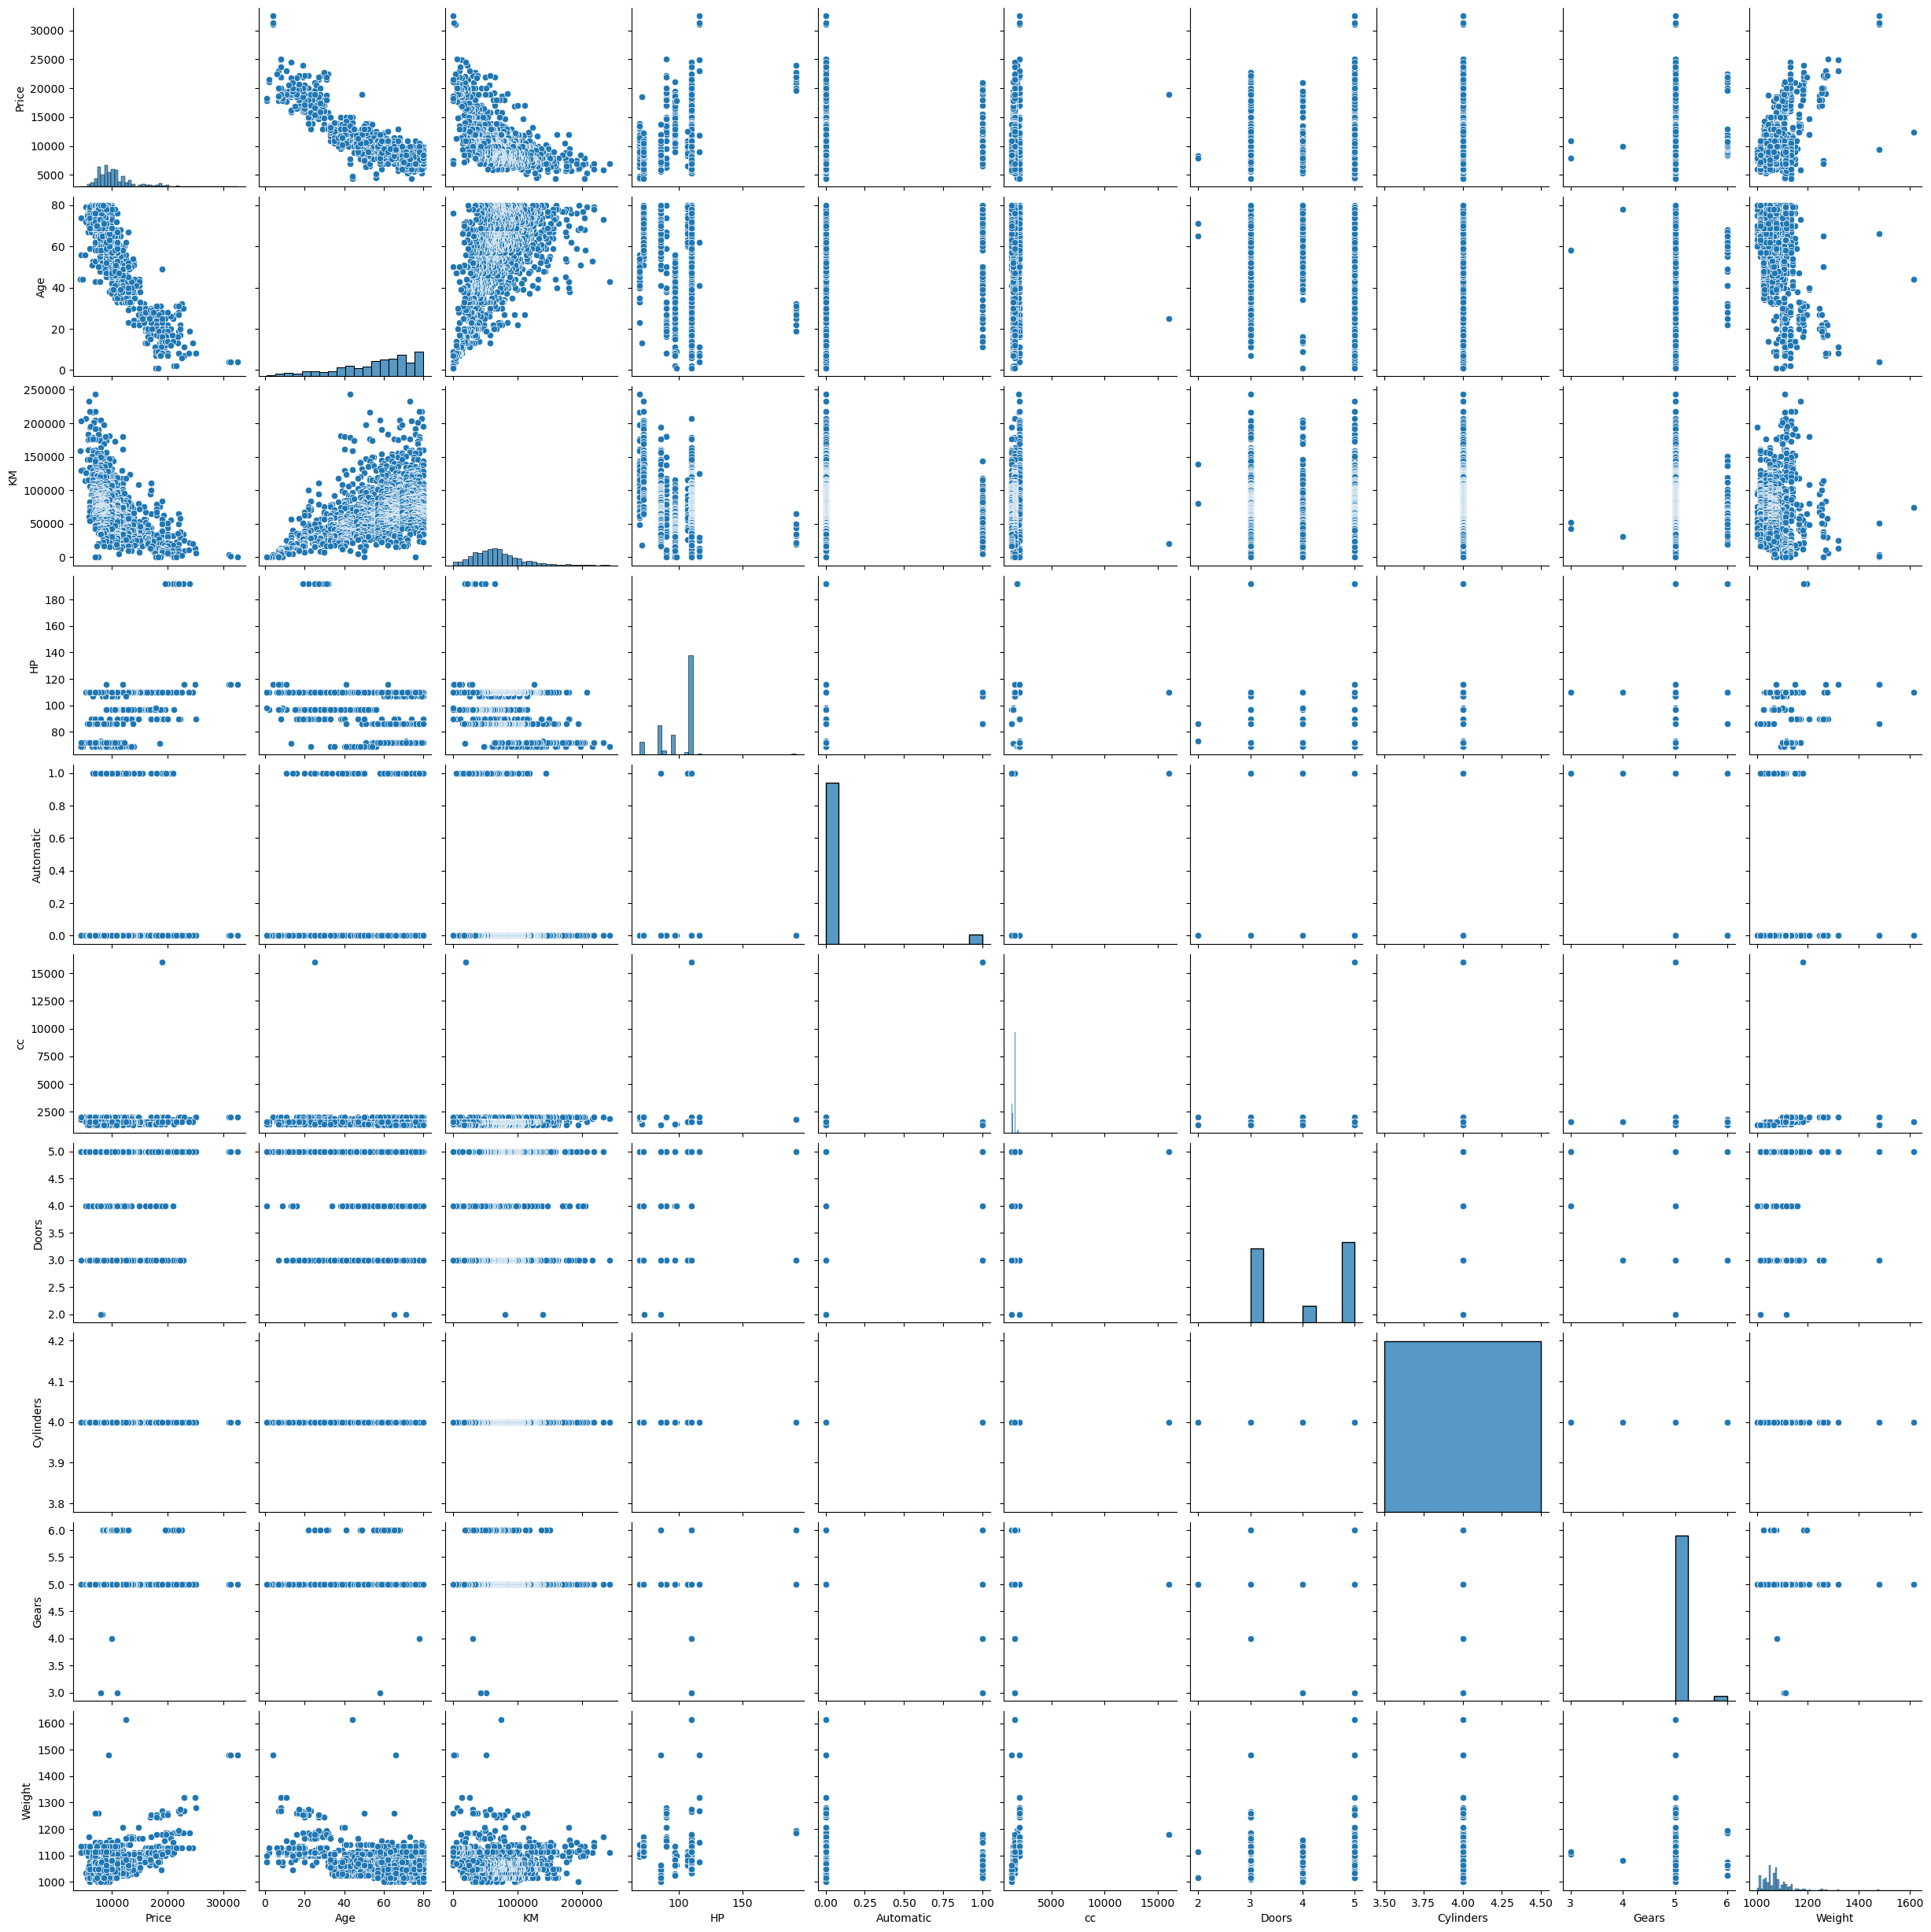

In [12]:
sns.pairplot(data)

In [13]:
num_col.var().sort_values()

Cylinders    0.000000e+00
Gears        3.553619e-02
Automatic    5.264333e-02
Doors        9.075927e-01
HP           2.244327e+02
Age          3.459596e+02
Weight       2.771088e+03
cc           1.801041e+05
Price        1.315487e+07
KM           1.406734e+09
dtype: float64

#### Cylinder Has Constant Variance... Soo we can drop that column

### Model 1 :  Row Data

In [14]:
data_raw.head(3)

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165


In [15]:
data_raw.select_dtypes(include='object').columns

Index(['Fuel_Type'], dtype='object')

In [16]:
data_raw = pd.get_dummies(data_raw, drop_first=True)

In [17]:
X = data_raw.drop('Price', axis=1)
y = data_raw['Price']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape , X_test.shape, y_train.shape, y_test.shape

((1148, 11), (288, 11), (1148,), (288,))

In [19]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [20]:
coef1 = pd.DataFrame(model1.coef_, X.columns, columns=['Coefficient'])
print(coef1)

                   Coefficient
Age_08_04        -1.208305e+02
KM               -1.623141e-02
HP                1.403948e+01
Automatic         1.488309e+02
cc               -3.037219e-02
Doors            -6.031097e+01
Cylinders        -1.620037e-12
Gears             5.516007e+02
Weight            2.588496e+01
Fuel_Type_Diesel -6.854876e+01
Fuel_Type_Petrol  1.370809e+03


#### The basic MLR model shows that age, kilometers, cc and Doors have a negative impact on price, while horsepower and weight positively influence price.

### Model 2 : After Outlier Handling

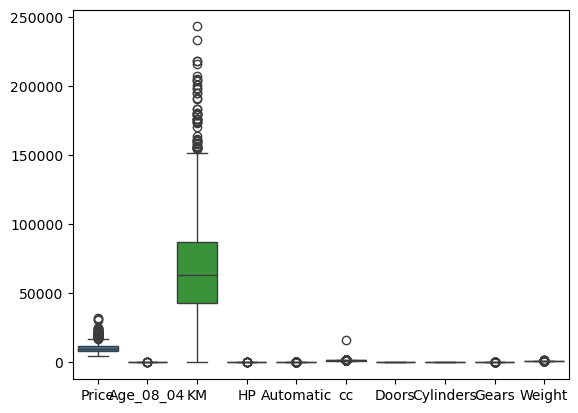

In [21]:
data_outlier.head()
#To check outliers we have to use boxplot and box plot work only with numeric variables 
num_col = data_outlier.select_dtypes(include=['int64'])
sns.boxplot(num_col)
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [23]:
scaler = StandardScaler()
le = LabelEncoder()

In [24]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])
    else:
        data[col] = scaler.fit_transform(data[[col]])

data.head()
        

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.763763,-1.771966,-0.574695,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
1,0.832715,-1.771966,0.117454,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
2,0.887877,-1.718184,-0.715386,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
3,1.163685,-1.610620,-0.547650,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
4,0.832715,-1.395491,-0.801028,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.853577


In [25]:
data.drop(columns= ['Cylinders'],axis=1)

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,0.763763,-1.771966,-0.574695,1,-0.768042,-0.242893,0.997419,-1.085139,-0.140425,1.758561
1,0.832715,-1.771966,0.117454,1,-0.768042,-0.242893,0.997419,-1.085139,-0.140425,1.758561
2,0.887877,-1.718184,-0.715386,1,-0.768042,-0.242893,0.997419,-1.085139,-0.140425,1.758561
3,1.163685,-1.610620,-0.547650,1,-0.768042,-0.242893,0.997419,-1.085139,-0.140425,1.758561
4,0.832715,-1.395491,-0.801028,1,-0.768042,-0.242893,0.997419,-1.085139,-0.140425,1.853577
...,...,...,...,...,...,...,...,...,...,...
1431,-0.891089,0.702015,-1.279939,2,-1.035138,-0.242893,-0.652594,-1.085139,-0.140425,-0.901883
1432,0.031491,0.863362,-1.321120,2,-1.035138,-0.242893,-0.652594,-1.085139,-0.140425,-1.091915
1433,-0.615281,0.809579,-1.374036,2,-1.035138,-0.242893,-0.652594,-1.085139,-0.140425,-1.091915
1434,-0.960042,0.755797,-1.376703,2,-1.035138,-0.242893,-0.652594,-1.085139,-0.140425,-1.091915


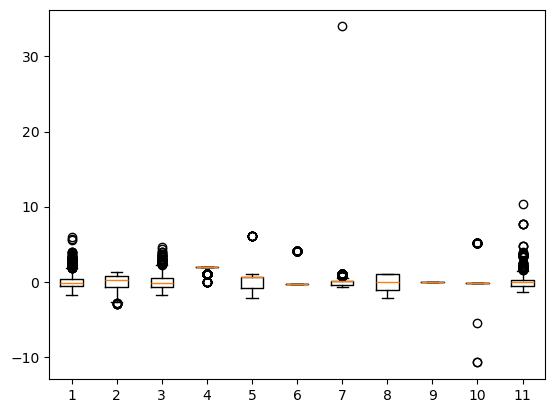

In [26]:
plt.boxplot(data)
plt.show()

#### According to boxplot we can see outliers are present in our data.

In [27]:
for col in num_col.columns:
    Q1 = num_col[col].quantile(0.25)
    Q3 = num_col[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    outliers = num_col[(num_col[col] > upper_bound) | (num_col[col] < lower_bound)]
    print(f"{col} : {outliers.shape[0]} outliers")

Price : 110 outliers
Age_08_04 : 7 outliers
KM : 49 outliers
HP : 11 outliers
Automatic : 80 outliers
cc : 123 outliers
Doors : 0 outliers
Cylinders : 0 outliers
Gears : 46 outliers
Weight : 66 outliers


#### Replace outliers with upper and lower bound values

In [28]:
for col in num_col.columns:
    
    Q1 = num_col[col].quantile(0.25)
    Q3 = num_col[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    num_col[col] = num_col[col].clip(lower_bound, upper_bound)

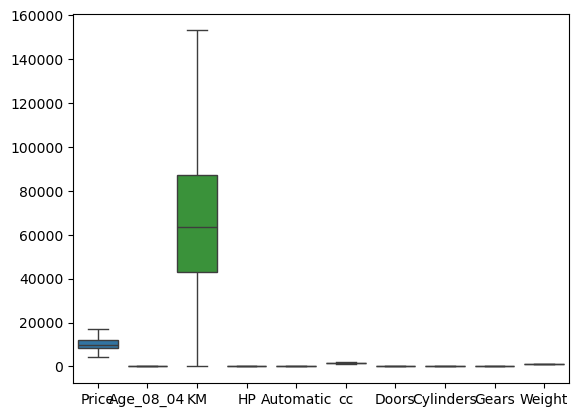

In [29]:
sns.boxplot(num_col)
plt.show()

In [30]:
X2 = num_col.drop('Price', axis=1)
y2 = num_col['Price']

In [31]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.2,random_state=42)
X2_train.shape , X2_test.shape, y2_train.shape, y2_test.shape

((1148, 9), (288, 9), (1148,), (288,))

In [32]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y_pred2 = model2.predict(X2_test)

In [33]:
coef2 = pd.DataFrame(model2.coef_, X2.columns, columns=['Coefficient'])
print(coef2)

            Coefficient
Age_08_04 -1.058707e+02
KM        -1.580781e-02
HP         2.655510e+01
Automatic  1.776357e-14
cc        -2.386055e+00
Doors     -8.305549e+01
Cylinders  0.000000e+00
Gears      0.000000e+00
Weight     2.370685e+01


### Model 3 (After Standardization)

In [34]:
data.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.763763,-1.771966,-0.574695,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
1,0.832715,-1.771966,0.117454,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
2,0.887877,-1.718184,-0.715386,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
3,1.163685,-1.610620,-0.547650,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
4,0.832715,-1.395491,-0.801028,1,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.853577


In [35]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [36]:
scaler = StandardScaler()
le = LabelEncoder()

In [37]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])
    else:
        data[col] = scaler.fit_transform(data[[col]])

data.head()
        

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.763763,-1.771966,-0.574695,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
1,0.832715,-1.771966,0.117454,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
2,0.887877,-1.718184,-0.715386,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
3,1.163685,-1.610620,-0.547650,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
4,0.832715,-1.395491,-0.801028,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.853577


#### Find Outliers

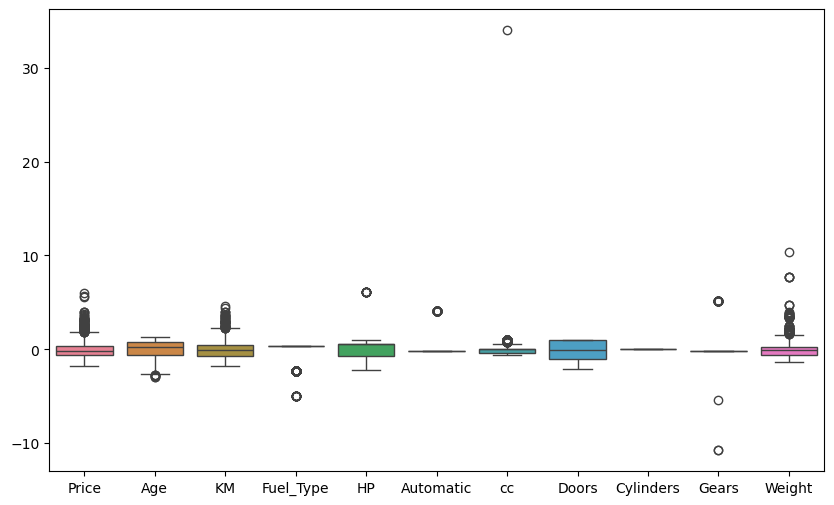

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data)
plt.show()

#### Remove the outliers

In [39]:
data.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.763763,-1.771966,-0.574695,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
1,0.832715,-1.771966,0.117454,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
2,0.887877,-1.718184,-0.715386,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
3,1.163685,-1.610620,-0.547650,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
4,0.832715,-1.395491,-0.801028,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.853577


In [40]:
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    outliers = data[(data[col] > upper_bound) | (data[col] < lower_bound)]
    print(f"{col} : {outliers.shape[0]} outliers")

Price : 110 outliers
Age : 7 outliers
KM : 49 outliers
Fuel_Type : 172 outliers
HP : 11 outliers
Automatic : 80 outliers
cc : 153 outliers
Doors : 0 outliers
Cylinders : 0 outliers
Gears : 46 outliers
Weight : 66 outliers


#### Replacing outliers with upeer and lower bound Values

In [41]:
for col in data.columns:
    
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower_bound, upper_bound)

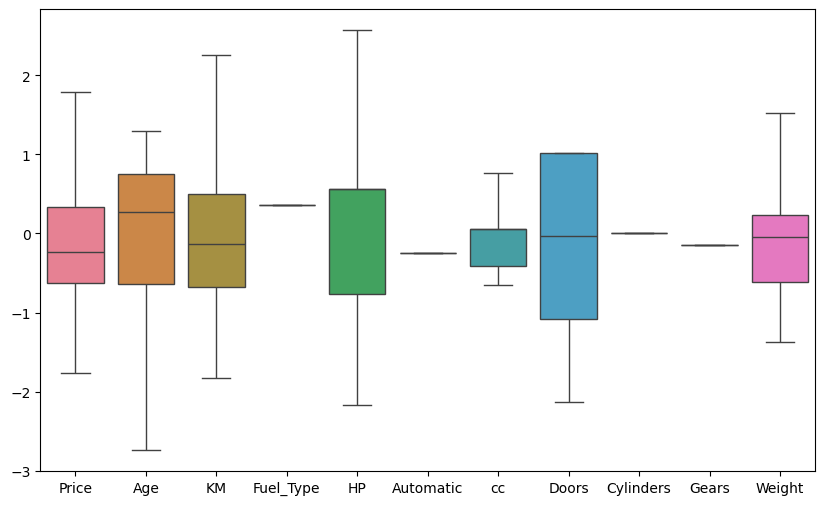

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data)
plt.show()

#### Now we have cleaned data soo will build the final model with cleaned data

In [43]:
X3 = data.drop(['Price'],axis=1)
y3 = data['Price']

In [44]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3,test_size=0.2,random_state=42)
X3_train.shape , X3_test.shape, y3_train.shape, y3_test.shape

((1148, 10), (288, 10), (1148,), (288,))

### Build the Model

In [45]:
model3 = LinearRegression()
model3.fit(X3_train,y3_train)

LinearRegression()

In [46]:
y_pred3 = model3.predict(X3_test)

In [47]:
coef3 = pd.DataFrame(model3.coef_, X3.columns, columns=['Coefficient'])
print(coef3)

            Coefficient
Age       -5.429315e-01
KM        -1.634686e-01
Fuel_Type  4.163336e-16
HP         1.096851e-01
Automatic -4.389918e-33
cc        -2.791894e-01
Doors     -2.181577e-02
Cylinders  0.000000e+00
Gears      0.000000e+00
Weight     3.440770e-01


#### 5. Apply Lasso and Ridge Regression

### Model 1:

In [55]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

# Ridge
ridge1 = Ridge(alpha=1.0)
ridge1.fit(X_train, y_train)
y_pred_ridge1 = ridge1.predict(X_test)

# Lasso
lasso1 = Lasso(alpha=1.0)
lasso1.fit(X_train, y_train)
y_pred_lasso1 = lasso1.predict(X_test)

# Evaluation
print("Ridge R2:", r2_score(y_test, y_pred_ridge1))
print("Lasso R2:", r2_score(y_test, y_pred_lasso1))

Ridge R2: 0.8351359377712336
Lasso R2: 0.8354626403967389


### Model 2

In [56]:
#ridge
ridge2 = Ridge(alpha=1.0)
ridge2.fit(X2_train, y2_train)
y_pred_ridge2 = ridge2.predict(X2_test)

#lasso
lasso2 = Lasso(alpha=1.0)
lasso2.fit(X2_train,y2_train)
y_pred_lasso2 = lasso2.predict(X2_test)

#Evaluation
print("Ridge R2:", r2_score(y2_test, y_pred_ridge2))
print("Lasso R2:", r2_score(y2_test, y_pred_lasso2))

Ridge R2: 0.8631889462760977
Lasso R2: 0.863177802901073


In [57]:
#Ridge Regression & Lasso Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X3_train, y3_train)
y_pred_ridge = ridge.predict(X3_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X3_train,y3_train)
y_pred_lasso = lasso.predict(X3_test)

#Evaluation
print("Ridge R2:", r2_score(y3_test, y_pred_ridge))
print("Lasso R2:", r2_score(y3_test, y_pred_lasso))

Ridge R2: 0.863184147701596
Lasso R2: -0.0017490747450981114


# 4. Evaluate Model Performance

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model 1
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
r21 = r2_score(y_test, y_pred1)

print("Model 1 -> MSE:", mse1, "RMSE:", rmse1, "R2:", r21)


# Model 2
mse2 = mean_squared_error(y2_test, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y2_test, y_pred2)

print("Model 2 -> MSE:", mse2, "RMSE:", rmse2, "R2:", r22)


# Model 3
mse3 = mean_squared_error(y3_test, y_pred3)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y3_test, y_pred3)

print("Model 3 -> MSE:", mse3, "RMSE:", rmse3, "R2:", r23)

Model 1 -> MSE: 2203043.8231437025 RMSE: 1484.2654153296514 R2: 0.8348888040611082
Model 2 -> MSE: 1175429.64470686 RMSE: 1084.1723316460625 R2: 0.8631898484529454
Model 3 -> MSE: 0.08941544626835081 RMSE: 0.29902415666355586 R2: 0.8631898484529454
